# Model Final Skripsi - Hybrid 4 Class Global

Ini adalah **jalur final utama** yang dipakai untuk skripsi dan integrasi WebGIS.

Model final:

- pendekatan: **Hybrid BiLSTM + XGBoost**
- target: **4 kelas curah hujan BMKG**
- cakupan: **seluruh Jakarta Timur**
- fitur spasial: **`Kecamatan` tetap dipakai sebagai fitur dummy**
- split data: **kronologis per kecamatan**
- imbalance handling: **class weight + SMOTE parsial di latent feature**
- mode keputusan final: **gated ensemble**
- deployment path: **backend membaca artefak dari retrain operasional**

Notebook ini dibuat supaya kamu punya **satu tempat utama** buat lihat:

- model final yang dipakai
- hasil metrik terakhir
- fitur dan split data
- kandidat XGBoost yang dipilih
- confusion matrix
- source code training yang penting
- cara rerun model dan refresh backend

## Cell 1 - Import dan Setup

In [1]:
import importlib
import inspect
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

import retrain_operational_multiclass_model as final_model
final_model = importlib.reload(final_model)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

## Cell 2 - Path Artefak Final

In [2]:
ROOT = Path(".").resolve()
SUMMARY_PATH = ROOT / "artifacts" / "latest_multiclass_training_summary.json"
CONFIG_PATH = ROOT / "operational_multiclass_config.json"
MODEL_PATH = ROOT / "model_bilstm_4class_jaktim.h5"
XGB_PATH = ROOT / "model_xgboost_4class_jaktim.pkl"
SCALER_PATH = ROOT / "scaler_4class_jaktim.pkl"
FEATURE_PATH = ROOT / "daftar_kolom_fitur_4class.pkl"

artifact_status_df = pd.DataFrame(
    [
        {"artifact": "summary_json", "path": str(SUMMARY_PATH), "exists": SUMMARY_PATH.exists()},
        {"artifact": "config_json", "path": str(CONFIG_PATH), "exists": CONFIG_PATH.exists()},
        {"artifact": "lstm_model", "path": str(MODEL_PATH), "exists": MODEL_PATH.exists()},
        {"artifact": "xgb_model", "path": str(XGB_PATH), "exists": XGB_PATH.exists()},
        {"artifact": "scaler", "path": str(SCALER_PATH), "exists": SCALER_PATH.exists()},
        {"artifact": "feature_columns", "path": str(FEATURE_PATH), "exists": FEATURE_PATH.exists()},
    ]
)
display(artifact_status_df)

,artifact,path,exists
0,summary_json,C:\Users\Vino\Documents\SKRIPSI\artifacts\late...,True
1,config_json,C:\Users\Vino\Documents\SKRIPSI\operational_mu...,True
2,lstm_model,C:\Users\Vino\Documents\SKRIPSI\model_bilstm_4...,True
3,xgb_model,C:\Users\Vino\Documents\SKRIPSI\model_xgboost_...,True
4,scaler,C:\Users\Vino\Documents\SKRIPSI\scaler_4class_...,True
5,feature_columns,C:\Users\Vino\Documents\SKRIPSI\daftar_kolom_f...,True


## Cell 3 - Identitas Model Final

In [3]:
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

final_identity_df = pd.DataFrame(
    [
        {
            "Pendekatan": "Hybrid BiLSTM + XGBoost",
            "Mode": "Global seluruh Jakarta Timur",
            "Target": "4 kelas BMKG",
            "Time Steps": summary["time_steps"],
            "Feature Count": summary["feature_count"],
            "Split": summary["split_summary"]["strategy"],
            "Kecamatan Sebagai Fitur": "Ya",
            "Ensemble Mode": config.get("ensemble_mode", "xgb_extreme_threshold"),
            "Gate Aktif": config.get("ensemble_rule", {}).get("enabled", False),
        }
    ]
)
display(final_identity_df)

,Pendekatan,Mode,Target,Time Steps,Feature Count,Split,Kecamatan Sebagai Fitur,Ensemble Mode,Gate Aktif
0,Hybrid BiLSTM + XGBoost,Global seluruh Jakarta Timur,4 kelas BMKG,5,26,chronological_per_district,Ya,gated_lstm_xgb_override,True


## Cell 4 - Kenapa Ini Yang Jadi Final

In [4]:
reasons = [
    "Model no_kecamatan turun lebih jauh dan gagal menangkap kelas ekstrem.",
    "Model regression tidak konsisten untuk kelas hujan lebat/ekstrem.",
    "Model two-stage tidak mengungguli model 4 class langsung.",
    "Model global 4 class paling masuk akal untuk tujuan skripsi dan jalur WebGIS.",
    "Mode gated ensemble dipilih karena menjaga akurasi lebih baik daripada hybrid XGBoost penuh, tanpa membuang total kelas ekstrem seperti LSTM murni.",
]

display(Markdown("\n".join([f"- {reason}" for reason in reasons])))

- Model no_kecamatan turun lebih jauh dan gagal menangkap kelas ekstrem.
- Model regression tidak konsisten untuk kelas hujan lebat/ekstrem.
- Model two-stage tidak mengungguli model 4 class langsung.
- Model global 4 class paling masuk akal untuk tujuan skripsi dan jalur WebGIS.
- Mode gated ensemble dipilih karena menjaga akurasi lebih baik daripada hybrid XGBoost penuh, tanpa membuang total kelas ekstrem seperti LSTM murni.

## Cell 5 - Fitur, Split, dan Distribusi Kelas

In [5]:
display(pd.DataFrame({"feature": summary["feature_columns"]}))

split_df = pd.DataFrame([summary["split_summary"]])
display(split_df[["strategy", "train_ratio", "val_ratio", "time_steps"]])

distribution_df = pd.DataFrame(
    [
        {"split": "total", **summary["class_distribution_total"]},
        {"split": "train", **summary["class_distribution_train"]},
        {"split": "val", **summary["class_distribution_val"]},
        {"split": "test", **summary["class_distribution_test"]},
    ]
).fillna(0)
display(distribution_df)

,feature
0,Curah Hujan (mm)
1,Hujan_3Hari_Kumulatif
2,Hujan_7Hari_Kumulatif
3,Hujan_7Hari_Maksimum
4,Hujan_Lag_1
5,Hujan_Lag_2
6,Hujan_Lag_3
7,Hujan_Lag_7
8,HariHujan_Beruntun
9,Suhu Rata-rata (C)


,strategy,train_ratio,val_ratio,time_steps
0,chronological_per_district,0.7,0.15,5


,split,0,1,2,3
0,total,75595,50932,6510,243
1,train,54040,35292,3804,104
2,val,11291,7558,1058,83
3,test,10254,8062,1638,46


## Cell 6 - Konfigurasi Training Final

In [6]:
print("LSTM config")
display(pd.DataFrame([summary["lstm_config"]]))

print("\nClass weights LSTM")
display(pd.DataFrame([summary["class_weights_lstm"]]))

print("\nSMOTE summary")
display(pd.DataFrame([summary["smote_summary"]]))

print("\nEnsemble rule final")
display(pd.DataFrame([summary["ensemble_rule"]]))

LSTM config


,units_1,units_2,dropout,dense_units,learning_rate,batch_size
0,64,32,0.2,16,0.001,64



Class weights LSTM


,0,1,2,3
0,0.65677,0.812705,2.475431,14.971126



SMOTE summary


,distribution_before,sampling_strategy,k_neighbors,distribution_after
0,"{'0': 54040, '1': 35292, '2': 3804, '3': 104}","{'2': 21616, '3': 5404}",5,"{'0': 54040, '1': 35292, '2': 21616, '3': 5404}"



Ensemble rule final


,enabled,class_2_threshold,class_3_threshold,class_2_margin,class_3_margin,selection_score,description
0,True,0.65,0.45,0.0,0.05,0.456975,LSTM menjadi prediksi dasar. XGBoost hanya bol...


## Cell 7 - Kandidat XGBoost dan Gate Terpilih

In [7]:
candidates_df = pd.DataFrame(
    [
        {
            "name": row["name"],
            "selection_score": row["selection_score"],
            "gated_val_acc": row["val_metrics_after_rule"]["accuracy"],
            "gated_val_macro_f1": row["val_metrics_after_rule"]["macro_f1"],
            "lstm_val_acc": row["val_metrics_lstm_argmax"]["accuracy"],
            "xgb_val_acc": row["val_metrics_argmax"]["accuracy"],
            "gated_val_critical_recall": row["val_metrics_after_rule"]["critical_recall"],
        }
        for row in summary["xgb_candidate_rows"]
    ]
).sort_values(
    by=["selection_score", "gated_val_acc", "gated_val_macro_f1"],
    ascending=False,
)
display(candidates_df)

print("\nBest XGBoost candidate")
display(
    pd.DataFrame(
        [
            {
                "name": summary["best_xgb_candidate"]["name"],
                "selection_score": summary["best_xgb_candidate"]["selection_score"],
                "gated_val_acc": summary["best_xgb_candidate"]["val_metrics_after_rule"]["accuracy"],
                "gated_val_macro_f1": summary["best_xgb_candidate"]["val_metrics_after_rule"]["macro_f1"],
                "lstm_val_acc": summary["best_xgb_candidate"]["val_metrics_lstm_argmax"]["accuracy"],
                "xgb_val_acc": summary["best_xgb_candidate"]["val_metrics_argmax"]["accuracy"],
            }
        ]
    )
)

,name,selection_score,gated_val_acc,gated_val_macro_f1,lstm_val_acc,xgb_val_acc,gated_val_critical_recall
3,XGB_4,0.456975,0.673987,0.389735,0.705903,0.618859,0.120482
0,XGB_1,0.455854,0.667434,0.387568,0.705903,0.614907,0.144578
1,XGB_2,0.455602,0.676238,0.387041,0.705903,0.618559,0.108434
2,XGB_3,0.454074,0.679290,0.388666,0.705903,0.622861,0.084337



Best XGBoost candidate


,name,selection_score,gated_val_acc,gated_val_macro_f1,lstm_val_acc,xgb_val_acc
0,XGB_4,0.456975,0.673987,0.389735,0.705903,0.618859


## Cell 8 - Metrik Final dan Pembanding Mode Prediksi

In [8]:
metrics_compare_df = pd.DataFrame(
    [
        {
            "stage": "final_gated_ensemble",
            "accuracy": summary["metrics"]["accuracy"],
            "macro_precision": summary["metrics"]["macro_precision"],
            "macro_recall": summary["metrics"]["macro_recall"],
            "macro_f1": summary["metrics"]["macro_f1"],
            "critical_precision": summary["metrics"]["critical_precision"],
            "critical_recall": summary["metrics"]["critical_recall"],
            "critical_f1": summary["metrics"]["critical_f1"],
        },
        {
            "stage": "lstm_argmax_only",
            "accuracy": summary["metrics_lstm_argmax"]["accuracy"],
            "macro_precision": summary["metrics_lstm_argmax"]["macro_precision"],
            "macro_recall": summary["metrics_lstm_argmax"]["macro_recall"],
            "macro_f1": summary["metrics_lstm_argmax"]["macro_f1"],
            "critical_precision": summary["metrics_lstm_argmax"]["critical_precision"],
            "critical_recall": summary["metrics_lstm_argmax"]["critical_recall"],
            "critical_f1": summary["metrics_lstm_argmax"]["critical_f1"],
        },
        {
            "stage": "xgb_argmax_only",
            "accuracy": summary["metrics_argmax"]["accuracy"],
            "macro_precision": summary["metrics_argmax"]["macro_precision"],
            "macro_recall": summary["metrics_argmax"]["macro_recall"],
            "macro_f1": summary["metrics_argmax"]["macro_f1"],
            "critical_precision": summary["metrics_argmax"]["critical_precision"],
            "critical_recall": summary["metrics_argmax"]["critical_recall"],
            "critical_f1": summary["metrics_argmax"]["critical_f1"],
        },
    ]
)
display(metrics_compare_df)

,stage,accuracy,macro_precision,macro_recall,macro_f1,critical_precision,critical_recall,critical_f1
0,final_gated_ensemble,0.58335,0.358706,0.370665,0.347611,0.012295,0.130435,0.022472
1,lstm_argmax_only,0.61310,0.310831,0.336914,0.320082,0.000000,0.000000,0.000000
2,xgb_argmax_only,0.53305,0.352844,0.388343,0.348189,0.009662,0.130435,0.017991


## Cell 9 - Interpretasi Trade-off

In [9]:
tradeoff_notes = [
    "Gated ensemble adalah model final yang dipakai di backend.",
    "LSTM-only biasanya memberi accuracy lebih tinggi, tetapi bisa gagal total di kelas ekstrem.",
    "XGBoost-only lebih sensitif ke kelas ekstrem, tetapi accuracy total cenderung turun.",
    "Gated ensemble dipilih sebagai kompromi: accuracy tetap naik dari hybrid lama, sambil menjaga deteksi kelas ekstrem tetap hidup.",
]

display(Markdown("\n".join([f"- {note}" for note in tradeoff_notes])))

- Gated ensemble adalah model final yang dipakai di backend.
- LSTM-only biasanya memberi accuracy lebih tinggi, tetapi bisa gagal total di kelas ekstrem.
- XGBoost-only lebih sensitif ke kelas ekstrem, tetapi accuracy total cenderung turun.
- Gated ensemble dipilih sebagai kompromi: accuracy tetap naik dari hybrid lama, sambil menjaga deteksi kelas ekstrem tetap hidup.

## Cell 10 - Confusion Matrix Final

,0_Cerah (<5mm),1_Ringan (5-20mm),2_Sedang (20-50mm),3_Lebat/Ekstrem (>=50mm)
0_Cerah (<5mm),6506,3420,188,140
1_Ringan (5-20mm),2283,4994,520,265
2_Sedang (20-50mm),299,1101,161,77
3_Lebat/Ekstrem (>=50mm),8,25,7,6


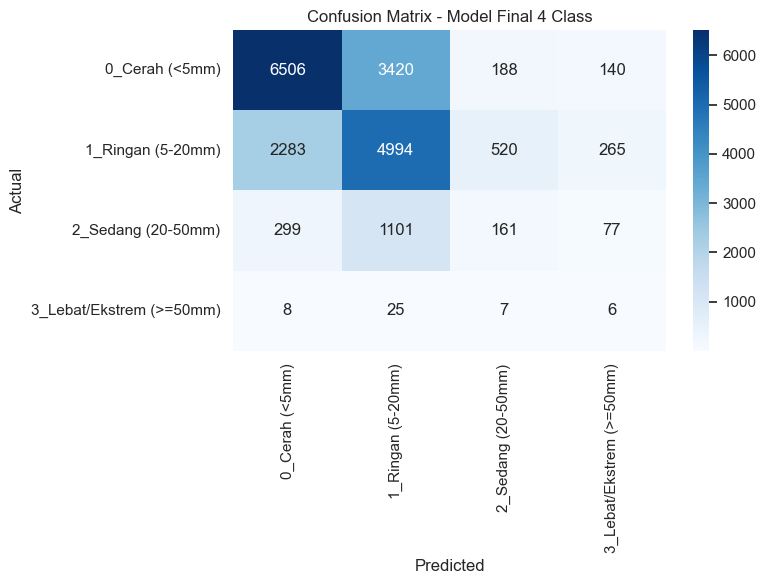

In [10]:
confusion_df = pd.DataFrame(
    summary["metrics"]["confusion_matrix"],
    index=final_model.CLASS_NAMES,
    columns=final_model.CLASS_NAMES,
)
display(confusion_df)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Model Final 4 Class")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Cell 11 - Kurva Training LSTM

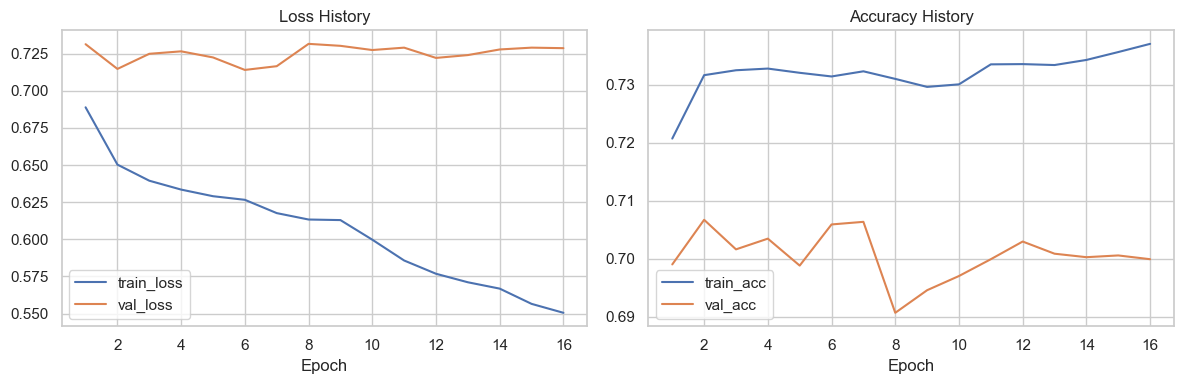

In [11]:
history_df = pd.DataFrame(summary["training_history"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df.index + 1, history_df["loss"], label="train_loss")
axes[0].plot(history_df.index + 1, history_df["val_loss"], label="val_loss")
axes[0].set_title("Loss History")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df.index + 1, history_df["accuracy"], label="train_acc")
axes[1].plot(history_df.index + 1, history_df["val_accuracy"], label="val_acc")
axes[1].set_title("Accuracy History")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Cell 12 - Source Code Pembentukan Data

In [12]:
print(inspect.getsource(final_model.prepare_feature_frame))
print(inspect.getsource(final_model.prepare_dataset))

def prepare_feature_frame() -> tuple[pd.DataFrame, list[str]]:
    df = pd.read_csv(DATASET_PATH, sep=";")
    df["Tanggal"] = pd.to_datetime(df["Tanggal"], format="%d/%m/%Y", dayfirst=True)
    df = df.dropna().sort_values(by=["Kecamatan", "Tanggal"]).reset_index(drop=True)
    df = engineer_temporal_features(df)
    df["Label"] = df["Curah Hujan (mm)"].apply(klasifikasi_hujan_4_kelas).astype(np.int8)

    district_order = sorted(df["Kecamatan"].unique().tolist())
    df_dummy = pd.get_dummies(pd.Categorical(df["Kecamatan"], categories=district_order), prefix="Kec")
    df = pd.concat([df, df_dummy], axis=1)

    feature_columns = [
        "Curah Hujan (mm)",
        "Hujan_3Hari_Kumulatif",
        "Hujan_7Hari_Kumulatif",
        "Hujan_7Hari_Maksimum",
        "Hujan_Lag_1",
        "Hujan_Lag_2",
        "Hujan_Lag_3",
        "Hujan_Lag_7",
        "HariHujan_Beruntun",
        "Suhu Rata-rata (C)",
        "Kelembapan Rata-rata (%)",
        "Kecepatan Angin Max (km/h)",
      

## Cell 13 - Source Code Model dan Balancing

In [13]:
print(inspect.getsource(final_model.build_lstm_model))
print(inspect.getsource(final_model.soft_class_weights))
print(inspect.getsource(final_model.partial_smote_strategy))
print(inspect.getsource(final_model.apply_manual_smote))
print(inspect.getsource(final_model.apply_gated_ensemble_rule))
print(inspect.getsource(final_model.compose_operational_probabilities))

def build_lstm_model(input_shape: tuple[int, int], feature_layer_name: str) -> Model:
    input_layer = Input(shape=input_shape)
    x = Bidirectional(LSTM(units=LSTM_CONFIG["units_1"], return_sequences=True))(input_layer)
    x = Dropout(LSTM_CONFIG["dropout"])(x)
    x = Bidirectional(LSTM(units=LSTM_CONFIG["units_2"], return_sequences=False))(x)
    x = Dropout(LSTM_CONFIG["dropout"])(x)
    feature_layer = Dense(
        units=LSTM_CONFIG["dense_units"],
        activation="relu",
        name=feature_layer_name,
    )(x)
    output_layer = Dense(units=4, activation="softmax")(feature_layer)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(
        optimizer=Adam(learning_rate=LSTM_CONFIG["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def soft_class_weights(y_train: np.ndarray) -> dict[int, float]:
    classes = np.unique(y_train)
    raw_weights = compute_class_weight(class_weig

## Cell 14 - Source Code Seleksi XGBoost dan Tuning Gate

In [14]:
print(inspect.getsource(final_model.tune_gated_ensemble_rule))
print(inspect.getsource(final_model.tune_xgb_candidates))

def tune_gated_ensemble_rule(
    y_true: np.ndarray,
    lstm_probabilities: np.ndarray,
    xgb_probabilities: np.ndarray,
) -> tuple[dict[str, Any], dict[str, Any], dict[str, Any], dict[str, Any], list[dict[str, Any]]]:
    baseline_lstm_predictions = np.argmax(lstm_probabilities, axis=1).astype(np.int8)
    baseline_lstm_metrics = summarize_metrics(
        y_true,
        baseline_lstm_predictions,
        lstm_probabilities,
        CLASS_NAMES,
    )
    baseline_xgb_predictions = np.argmax(xgb_probabilities, axis=1).astype(np.int8)
    baseline_xgb_metrics = summarize_metrics(
        y_true,
        baseline_xgb_predictions,
        xgb_probabilities,
        CLASS_NAMES,
    )

    best_metrics = baseline_lstm_metrics
    best_rule = {
        "enabled": False,
        "class_2_threshold": 1.0,
        "class_3_threshold": 1.0,
        "class_2_margin": 0.0,
        "class_3_margin": 0.0,
        "selection_score": round(model_selection_score(baseline_lstm_metrics), 6),
     

## Cell 15 - Source Code Main Training Final

In [15]:
print(inspect.getsource(final_model.main))

def main() -> None:
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = ARTIFACTS_DIR / f"retrain_multiclass_{timestamp}"
    run_dir.mkdir(parents=True, exist_ok=True)

    print("Menyiapkan dataset 4 class dari source 1990-sekarang...")
    dataset = prepare_dataset()
    print(f"Train: {dataset.X_train.shape} | Val: {dataset.X_val.shape} | Test: {dataset.X_test.shape}")
    print(f"Jumlah fitur per time step: {dataset.X_train.shape[2]}")
    print(f"Distribusi label total: {dataset.class_distribution_total}")
    print("Split data: kronologis per kecamatan, scaler fit hanya pada periode train.")

    class_weights = soft_class_weights(dataset.y_train)
    print(f"Class weights LSTM: {class_weights}")

    model_lstm = build_lstm_model(
        (dataset.X_train.shape[1], dataset.X_train.shape[2]),
        feature_layer_name="feature_layer",
    )
    early_stop = EarlyStopping(monitor="val_loss", patience=10, r

## Cell 16 - Cara Rerun Model Final

Jalankan cell ini hanya kalau memang mau retrain ulang.

In [16]:
JALANKAN_RETRAIN = False

if JALANKAN_RETRAIN:
    result = subprocess.run(
        [sys.executable, "retrain_operational_multiclass_model.py"],
        check=True,
        text=True,
        capture_output=True,
    )
    print(result.stdout)
else:
    print("Retrain dimatikan. Ubah JALANKAN_RETRAIN = True kalau mau menjalankan ulang.")

Retrain dimatikan. Ubah JALANKAN_RETRAIN = True kalau mau menjalankan ulang.


## Cell 17 - Cara Refresh Output Backend WebGIS

In [17]:
print("Perintah terminal yang dipakai:")
print("python retrain_operational_multiclass_model.py")
print("python webgis_backend.py --export-static-json --no-serve")

Perintah terminal yang dipakai:
python retrain_operational_multiclass_model.py
python webgis_backend.py --export-static-json --no-serve


## Cell 18 - Kalimat Singkat Buat Sidang

Kalau mau jelasin cepat:

- model final yang digunakan adalah **Hybrid BiLSTM + XGBoost dengan gated ensemble**
- targetnya **4 kelas curah hujan BMKG**
- data diproses secara **kronologis per kecamatan**
- fitur lokasi **tetap dipakai** karena eksperimen tanpa fitur kecamatan justru menurunkan performa
- LSTM dipakai sebagai prediksi dasar, lalu XGBoost hanya mengoreksi ke kelas lebih tinggi saat sinyalnya cukup kuat
- hasil model kemudian dihubungkan ke backend WebGIS melalui artefak operasional